<div style="text-align: right;">
<img src="TSs_Logo_UTN.svg" width="150" />
</div>

---

<h2 style="text-align: center;">Departamento de Electrónica</h2>

<h3 style="text-align: center;">(950416) Procesamiento Digital de Señales - R6051</h3>

<p style="text-align: center;">
<strong>Docente</strong><br>
Dr. Ing. Mariano Llamedo Soria
</p>

---

<h1 style="text-align: center;"> 2° Tarea semanal: Algoritmo para calcular la DFT</h1>

---

Por ***David Moharos***

---

## Consigna

Desarrollar un algoritmo que calcule la transformada discreta de Fourier (DFT).

$$X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-j 2\pi \cdot k \cdot n / N}$$
    
XX = mi_funcion_DFT( xx )

xx: señal a analizar, una matriz ($Nx1$) de números reales.

XX: DFT de xx, una matriz ($Nx1$) de números complejos.

Aprovechando que el generador de señales de la tarea anterior, y recordando que la DFT de una senoidal de frecuencia $f_0$, será una delta de Kronecker posicionada en la frecuencia $f_0$, validar la función a partir de esta experiencia.

####

***

## Introducción y configuración
En esta sección se importan las librerías necesarias (`numpy`, `matplotlib.pyplot` y `scipy.signal`) y se definen los parámetros globales de la simulación, como la frecuencia de muestreo y las frecuencias de las señales a generar.

In [1]:
# Importación de módulos que utilizaremos:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

#%% Parámetros de ejemplo
N  = 8    # cantidad de muestras
fs = N    # frecuencia de muestreo
f0 = 2    # frecuencia de señal senoidal

####

***

## Definición de funciones
A continuación, se definen las funciones para generar una señal **senoidal**, y calcular la **DFT**. `funcion_senal_senoidal` devuelve un vector de tiempo `tt` y un vector de amplitud `xx` de dimensiones $N \times 1$, mientras que la `funcion_DFT` devuelve una matriz de números complejos `XX` de dimensiones $N \times 1$.

In [2]:
#%%  Señal senoidal
def funcion_senal_senoidal(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima [V]
    dc   -- Valor medio [V]
    ff   -- Frecuencia de la senoidal [Hz]
    ph   -- Fase [rad]
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo [Hz]
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Vector de tiempo tt
    tt = np.arange(nn * 1/fs, step = 1/fs)
    
    # Vector de señal senoidal
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx
    

In [3]:
#%%  Algoritmo DFT - 1° Implementación
def funcion_DFT_1(xx):
    N = len(xx)
    XX = np.zeros(N, dtype=complex)
    
    for k in range(N):
        for n in range(N):
            XX[k] += xx[n] * np.exp(-1j * 2 * np.pi * k * n / N)

    return XX

In [4]:
#%%  Algoritmo DFT - 2° Implementación

def funcion_DFT_2(xx):
    N = len(xx)
    n = np.arange(N)                        # vector FILA de N elementos equiespaciados
    k = n.reshape((N, 1))                   # vector COLUMNA de N elementos equiespaciados
    
    yy = np.exp(-2j * np.pi * k * n / N)    # matriz de N x N elementos
    
    XX = np.dot(yy, xx)                     # producto punto entre x[n] * e^{-j 2*pi * k * n / N}
    
    return XX

####

***

## Generación y visualización de análisis 
Se procede a instanciar la senoidal y analizar su DFT, utilizando las funciones definidas anteriormente, para luego graficarlas y verificar su correcto funcionamiento en el dominio del tiempo y frecuencia. 


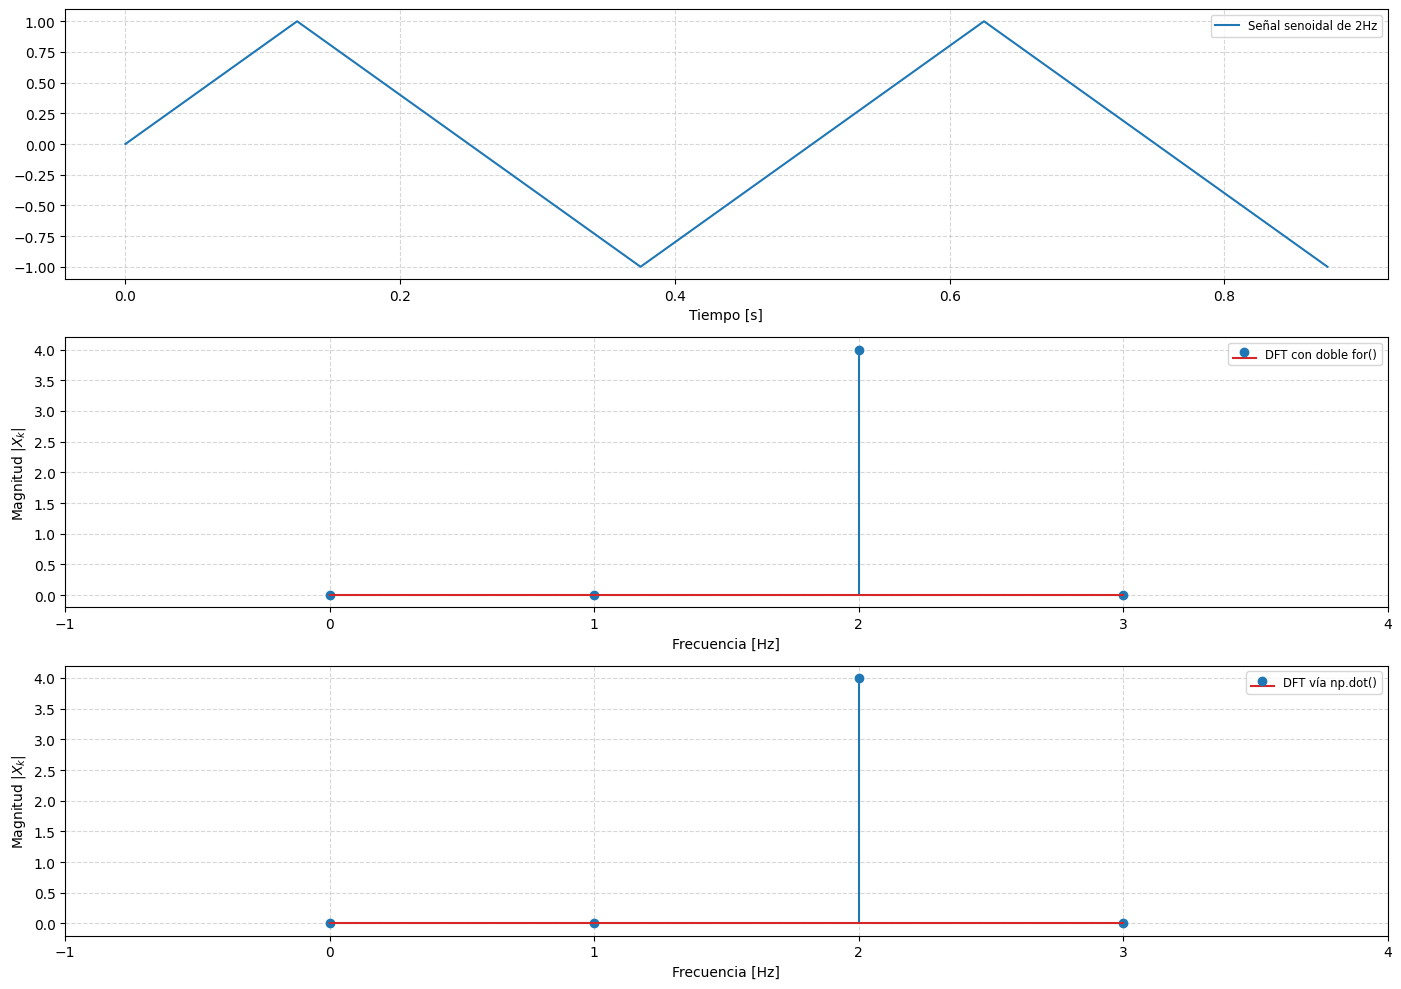

In [64]:
#%% Señal senoidal
tt, xx = funcion_senal_senoidal(vmax=1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

#%% Cálculo de la DFT
XX_1 = funcion_DFT_1(xx)
XX_2 = funcion_DFT_2(xx)
ff = np.arange(N)

#%% Representaciones gráficas
plt.figure(figsize=(14, 10))
fil = 3 
col = 1

# Señal senoidal
plt.subplot(fil, col, 1)
plt.plot(tt, xx, label=f"Señal senoidal de {f0}Hz")
plt.legend(loc='upper right', fontsize='small')
plt.xlabel("Tiempo [s]")
plt.grid(True, linestyle='--', alpha=0.5)

# Espectro de la señal senoidal - 1° Implementación - Doble for()
plt.subplot(fil, col, 2)
plt.stem(ff[:N//2], np.abs(XX_1[:N//2]), label="DFT con doble for()")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud $|X_k|$")
plt.xlim(-1, 4)
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)

# Espectro de la señal senoidal - 2° Implementación - Vía np.dot()
plt.subplot(fil, col, 3)
plt.stem(ff[:N//2], np.abs(XX_2[:N//2]), label="DFT vía np.dot()")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud $|X_k|$")
plt.xlim(-1, 4)
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

En la primera imagen, observamos la señal senoidal de frecuencia $f_0$ de $2 Hz$ muestreada a una frecuencia $f_s$ de $8 Hz$, a razón de $N = 8$ muestras. Debido a la cantidad de muestras y la interpolación entre muestras que realiza la función, se observa lo que pareciera ser a priori una función triangular. Sin embargo, la representación se corresponde con dos ciclos de la señal senoidal en concordancia tanto con su frecuencia $f_0$ como con la ventana de muestreo de $1 s$.

En la segunda y tercera imagen, se observa el espectro de Fourier vía aplicación del núcleo de transformación de la DFT, por caso, mediante dos implementaciones en apariencia similares pero resulta una ser un tanto más eficiente computacionalmente que la otra. Como es de esperar, se obtienen los mismos resultados, lo que nos permite validar la implementación de dichas funciones.

El espectro guarda simetría respecto del eje de magnitud de esta pseudo representación, por lo tanto se representa únicamente la parte correspondiente a las frecuencias positivas: de igual manera, el espectro se replica en la porción del espectro correspondiente a las frencuencias negativas.

Dichas representaciones espectrales se corresponden con la transformada de Fourier de una función senoidal: una delta de Kronecker precisamente en $f_0 = 2 Hz$ como habíamos adelantado al inicio del presente trabajo. Una vez más, de forma similar, esperaríamos observar una delta a su vez en $-f_0$.

####

***

##  Bonus:

💎 Probar las mismas experiencias con la transformada rápida de Fourier (DFT rápida se llama FFT).

🤯 Calcular la DFT de una señal aleatoria, por ejemplo ruido uniforme de varianza σ² = 4. Pueden encontrar cómo depende la varianza de los parámetros de la distribución aquí.

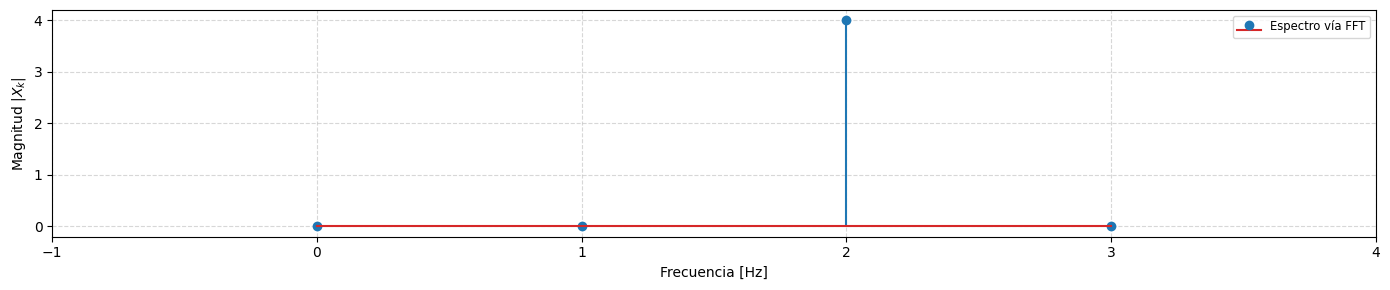

In [38]:
#%% Espectro de la señal senoidal - Vía FFT

# Cálculo de la FFT
YY_1 = np.fft.fft(xx)
ff = np.arange(N)

plt.figure(figsize=(14, 3))
plt.stem(ff[:N//2], np.abs(YY_1[:N//2]), label="Espectro vía FFT")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud $|X_k|$")
plt.xlim(-1, 4)
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Como se puede observar, se obtienen los mismos resultados vía FFT que los obtenidos anteriormente a partir de ambas implementaciones de la DFT.

####

***

####

A continuación, se evalúa la DFT de una señal aleatoria, por caso, una señal de ruido uniforme de varianza $\sigma^2 = 4$.

Para una distribución uniforme, la varianza de una variable aleatoria $X$ de forma general viene dada por la expresión:

###

\begin{equation*}
\text{Var}[X] = \text{E}\left[(X - \text{E}[X])^2\right] = \int_a^b \left(x - \frac{a+b}{2}\right)^2 \frac{dx}{b-a} = \frac{(b-a)^2}{12}
\end{equation*}

###

De esta manera, conociendo la expresión de la varianza y su valor, queda definido nuestro intervalo de interés: $L = b-a = \sqrt{48}$

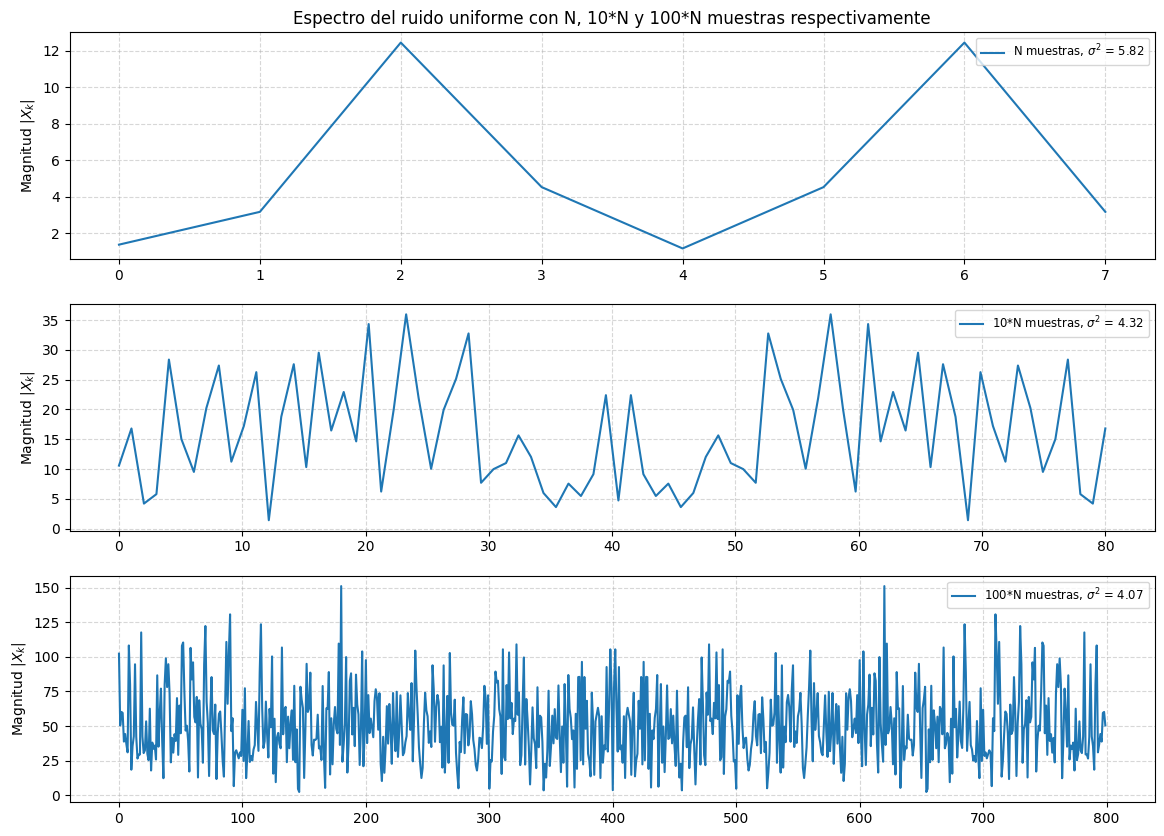

In [68]:
#%% Obtención del espectro de ruido uniforme
L = np.sqrt(48)

xx_nn_t_N = np.random.uniform(-L/2, L/2, N)
xx_nn_t_10N = np.random.uniform(-L/2, L/2, 10*N)
xx_nn_t_100N = np.random.uniform(-L/2, L/2, 100*N)

XX_nn_e_N = funcion_DFT_1(xx_nn_t_N)
XX_nn_e_10N = funcion_DFT_1(xx_nn_t_10N)
XX_nn_e_100N = funcion_DFT_1(xx_nn_t_100N)

#%% Representación gráfica
plt.figure(figsize=(14, 10))
fil = 3 
col = 1

# Espectro de ruido uniforme N = 8
plt.subplot(fil, col, 1)
plt.title(f"Espectro del ruido uniforme con N, 10*N y 100*N muestras respectivamente")
plt.plot(ff, np.abs(XX_nn_e_N), label=f"N muestras, $\sigma^2$ = {np.var(xx_nn_t_N):.2f}")
plt.legend(loc='upper right', fontsize='small')
plt.ylabel("Magnitud $|X_k|$")
plt.grid(True, linestyle='--', alpha=0.5)

# Espectro de ruido uniforme N = 10*N
plt.subplot(fil, col, 2)
plt.plot(np.linspace(0,10*N,10*N), np.abs(XX_nn_e_10N), label=f"10*N muestras, $\sigma^2$ = {np.var(xx_nn_t_10N):.2f}")
plt.legend(loc='upper right', fontsize='small')
plt.ylabel("Magnitud $|X_k|$")
plt.grid(True, linestyle='--', alpha=0.5)

# Espectro de ruido uniforme N = 100*N
plt.subplot(fil, col, 3)
plt.plot(np.linspace(0,100*N - 1,100*N), np.abs(XX_nn_e_100N), label=f"100*N muestras, $\sigma^2$ = {np.var(xx_nn_t_100N):.2f}")
plt.legend(loc='upper right', fontsize='small')
plt.ylabel("Magnitud $|X_k|$")
plt.grid(True, linestyle='--', alpha=0.5)


El espectro del ruido uniforme distribuye su energía a lo largo de toda la banda de frecuencias, a diferencia de una señal senoidal que concentra su energía en componentes discretas.

Se puede observar un espectro plano en valor medio, acompañado de fluctuaciones aleatorias en cada bin, situación que nos permite validar de forma práctica la definición de ruido blanco, cuya densidad espectral de potencia es constante para todo el espectro.

Por último, se puede observar que la varianza temporal de la muestra generada numéricamente a partir de `numpy.var()`, converge al valor teórico de $\sigma^2 = 4.00$. Cabe aclarar que esto ocurre en la medida que la cantidad de muestras sea representativa: notar que se produce una mayor convergencia, cuanto mayor es el número de muestras.